# Monthly Behavioral Perspective
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

Monthly Behavioral segmentation, analyzing purchasing habits and travel behaviors

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#1st-bullet)<br>

[**Data Preposessing**](#2nd-bullet)<br>

    
</div>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import warnings

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import silhouette_score, silhouette_samples # new library
from sklearn.cluster import KMeans # new library
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_context("notebook")
sns.set_style("ticks")

In [42]:
df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

# By Month

In [43]:
M_Behavioral_columns = df_AIAI_Master.columns.to_list()[-48:]

df_AIAI_M_Behavioral = df_AIAI_Master[M_Behavioral_columns].copy()
df_AIAI_M_Behavioral.head()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610
549612,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500
429460,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764.0,6097.0,30356.0,0.0,6110.0,0.0,0.0,16881.0,56823.0,0.0,1030.0,45760.0,0.000000,75.000000,86.666667,0.000000,8.695652,0.000000,0.0,80.952381,0.000000,0.000000,0.000000,100.000000,66.7543,-48.7079,30.3493,0.0000,6.1044,0.0000,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556
608370,11.0,21.0,31.0,13.0,24.0,37.0,0.0,0.0,19.0,22.0,2.0,16.0,49255.0,35206.0,65665.0,37464.0,38224.0,45139.0,0.0,0.0,9285.0,53130.0,29241.0,23421.0,72.727273,52.380952,41.935484,0.000000,16.666667,0.000000,0.0,0.000000,10.526316,59.090909,0.000000,43.750000,-13.7374,-31.4985,65.6521,37.4562,38.2229,45.1288,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270
530508,0.0,22.0,4.0,0.0,24.0,15.0,21.0,38.0,8.0,0.0,24.0,15.0,0.0,19731.0,5566.0,0.0,47106.0,54063.0,55404.0,73431.0,68327.0,0.0,40863.0,2122.0,0.000000,40.909091,100.000000,0.000000,25.000000,60.000000,0.0,34.210526,100.000000,0.000000,41.666667,26.666667,0.0000,19.7142,5.5600,0.0000,47.0977,54.0565,55.3928,73.4215,68.3248,0.0000,40.8525,2.1200


In [44]:
df_AIAI_M_Behavioral.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 48 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Total_NumFlights_month_1               15101 non-null  float64
 1   Total_NumFlights_month_2               15101 non-null  float64
 2   Total_NumFlights_month_3               15101 non-null  float64
 3   Total_NumFlights_month_4               15101 non-null  float64
 4   Total_NumFlights_month_5               15101 non-null  float64
 5   Total_NumFlights_month_6               15101 non-null  float64
 6   Total_NumFlights_month_7               15101 non-null  float64
 7   Total_NumFlights_month_8               15101 non-null  float64
 8   Total_NumFlights_month_9               15101 non-null  float64
 9   Total_NumFlights_month_10              15101 non-null  float64
 10  Total_NumFlights_month_11              15101 non-null  float64
 11  T

In [45]:
df_AIAI_M_Behavioral.isna().sum()

Total_NumFlights_month_1                 1471
Total_NumFlights_month_2                 1471
Total_NumFlights_month_3                 1471
Total_NumFlights_month_4                 1471
Total_NumFlights_month_5                 1471
Total_NumFlights_month_6                 1471
Total_NumFlights_month_7                 1471
Total_NumFlights_month_8                 1471
Total_NumFlights_month_9                 1471
Total_NumFlights_month_10                1471
Total_NumFlights_month_11                1471
Total_NumFlights_month_12                1471
Total_DistanceKM_month_1                 1471
Total_DistanceKM_month_2                 1471
Total_DistanceKM_month_3                 1471
Total_DistanceKM_month_4                 1471
Total_DistanceKM_month_5                 1471
Total_DistanceKM_month_6                 1471
Total_DistanceKM_month_7                 1471
Total_DistanceKM_month_8                 1471
Total_DistanceKM_month_9                 1471
Total_DistanceKM_month_10         

In [46]:
# Filter rows with any missing values into a new dataframe and add No_transactions (count of missing per row)
df_AIAI_M_Behavioral_classified = df_AIAI_M_Behavioral[df_AIAI_M_Behavioral.isna().any(axis=1)].copy()
df_AIAI_M_Behavioral_classified['Final_Cluster'] = 'No_transactions'

# Remove those observations from the original dataframe
df_AIAI_M_Behavioral = df_AIAI_M_Behavioral.drop(df_AIAI_M_Behavioral_classified.index)

df_AIAI_M_Behavioral_classified.head()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Final_Cluster
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
201574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
834891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
329382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
357549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
283314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions


In [47]:
df_AIAI_M_Behavioral.isna().sum()

Total_NumFlights_month_1                 0
Total_NumFlights_month_2                 0
Total_NumFlights_month_3                 0
Total_NumFlights_month_4                 0
Total_NumFlights_month_5                 0
Total_NumFlights_month_6                 0
Total_NumFlights_month_7                 0
Total_NumFlights_month_8                 0
Total_NumFlights_month_9                 0
Total_NumFlights_month_10                0
Total_NumFlights_month_11                0
Total_NumFlights_month_12                0
Total_DistanceKM_month_1                 0
Total_DistanceKM_month_2                 0
Total_DistanceKM_month_3                 0
Total_DistanceKM_month_4                 0
Total_DistanceKM_month_5                 0
Total_DistanceKM_month_6                 0
Total_DistanceKM_month_7                 0
Total_DistanceKM_month_8                 0
Total_DistanceKM_month_9                 0
Total_DistanceKM_month_10                0
Total_DistanceKM_month_11                0
Total_Dista

# Outliers Vizualizations

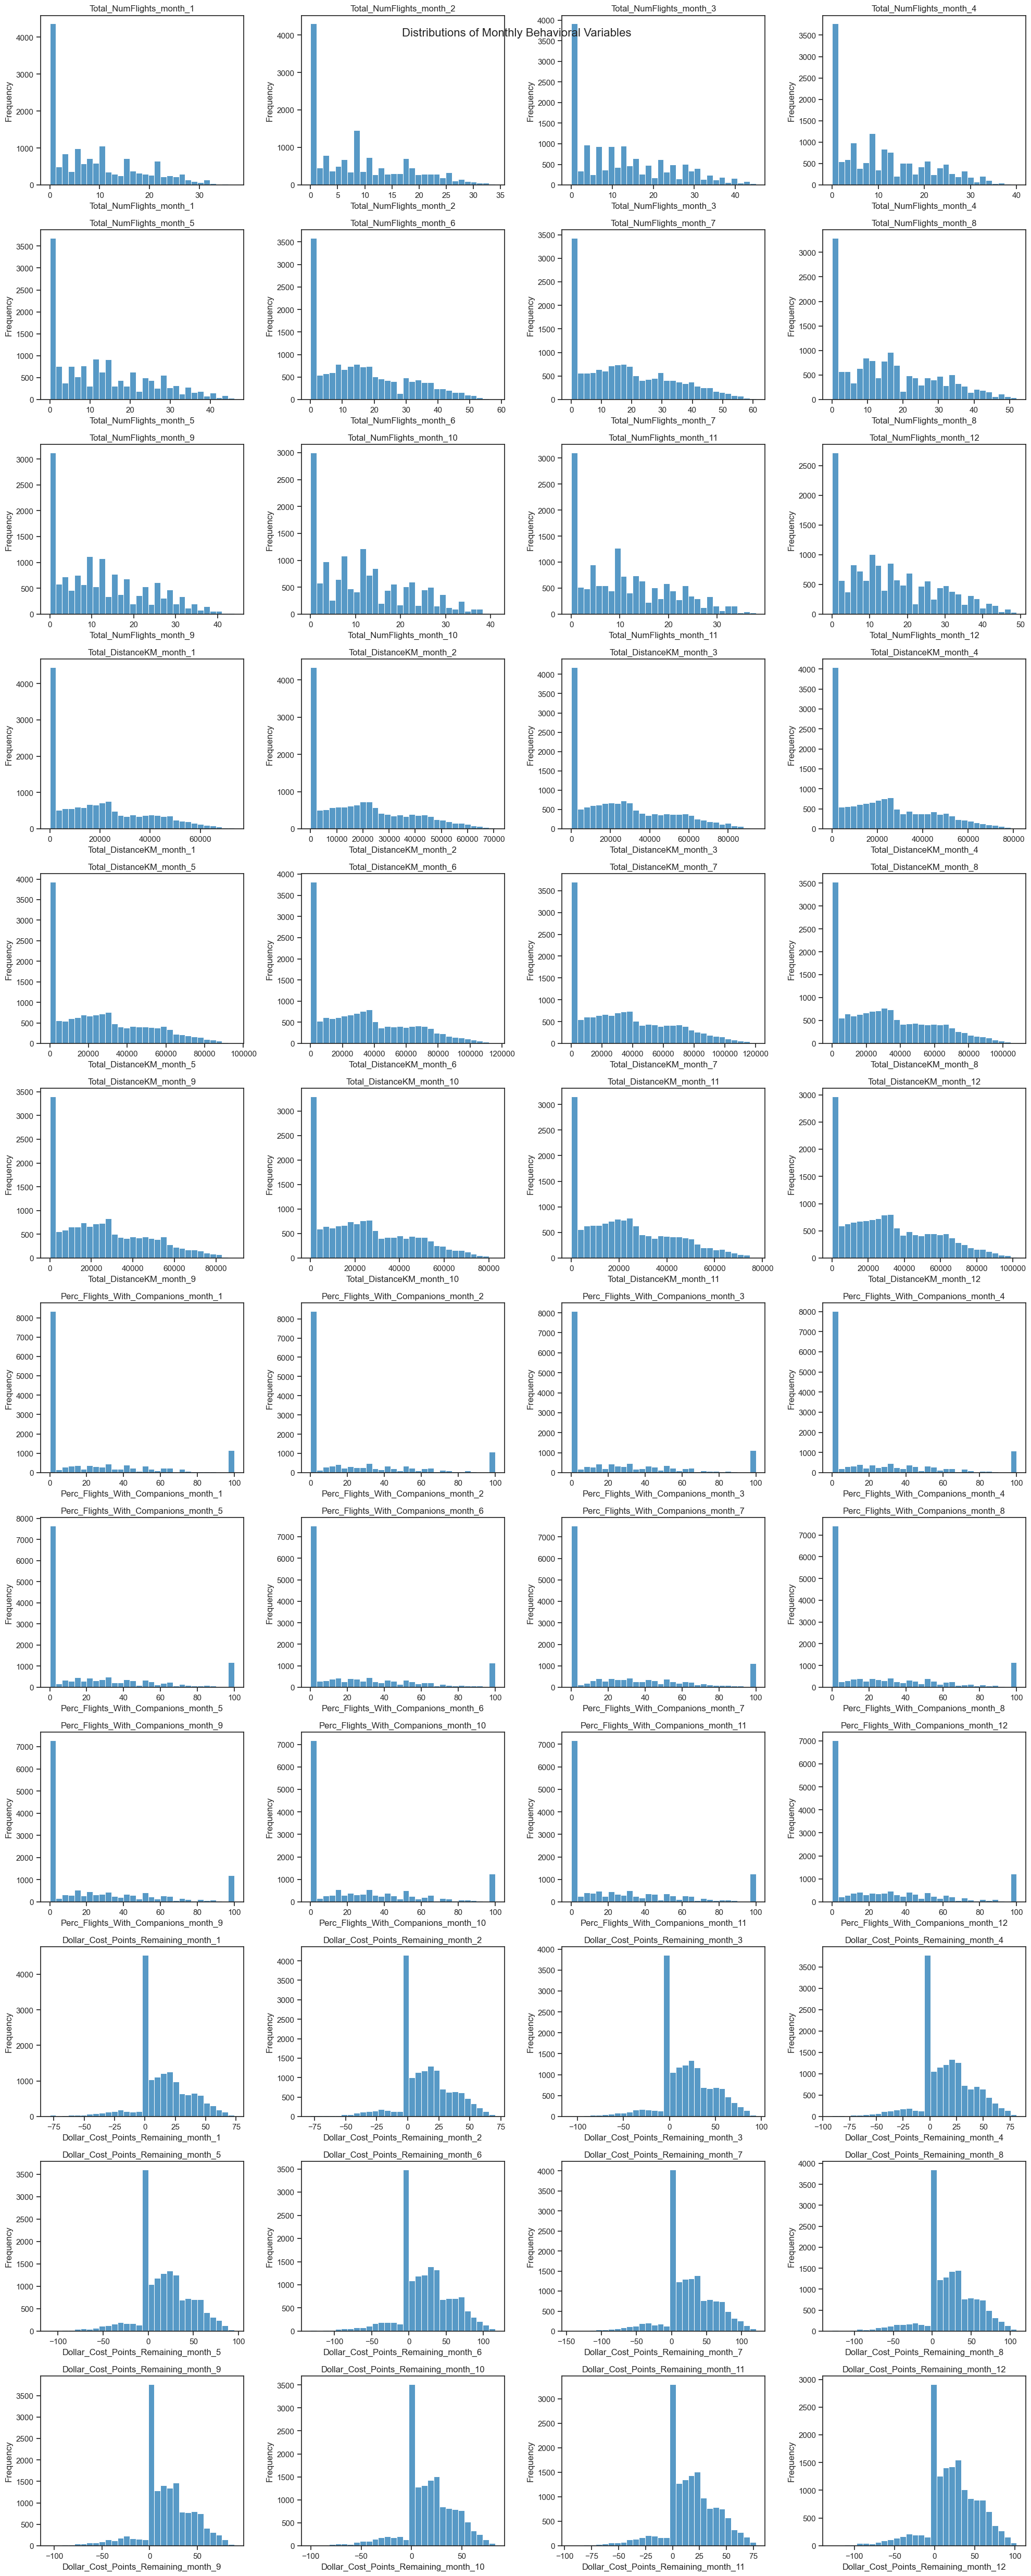

In [41]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Monthly Behavioral Variables", fontsize=16)
plt.tight_layout()
plt.show()

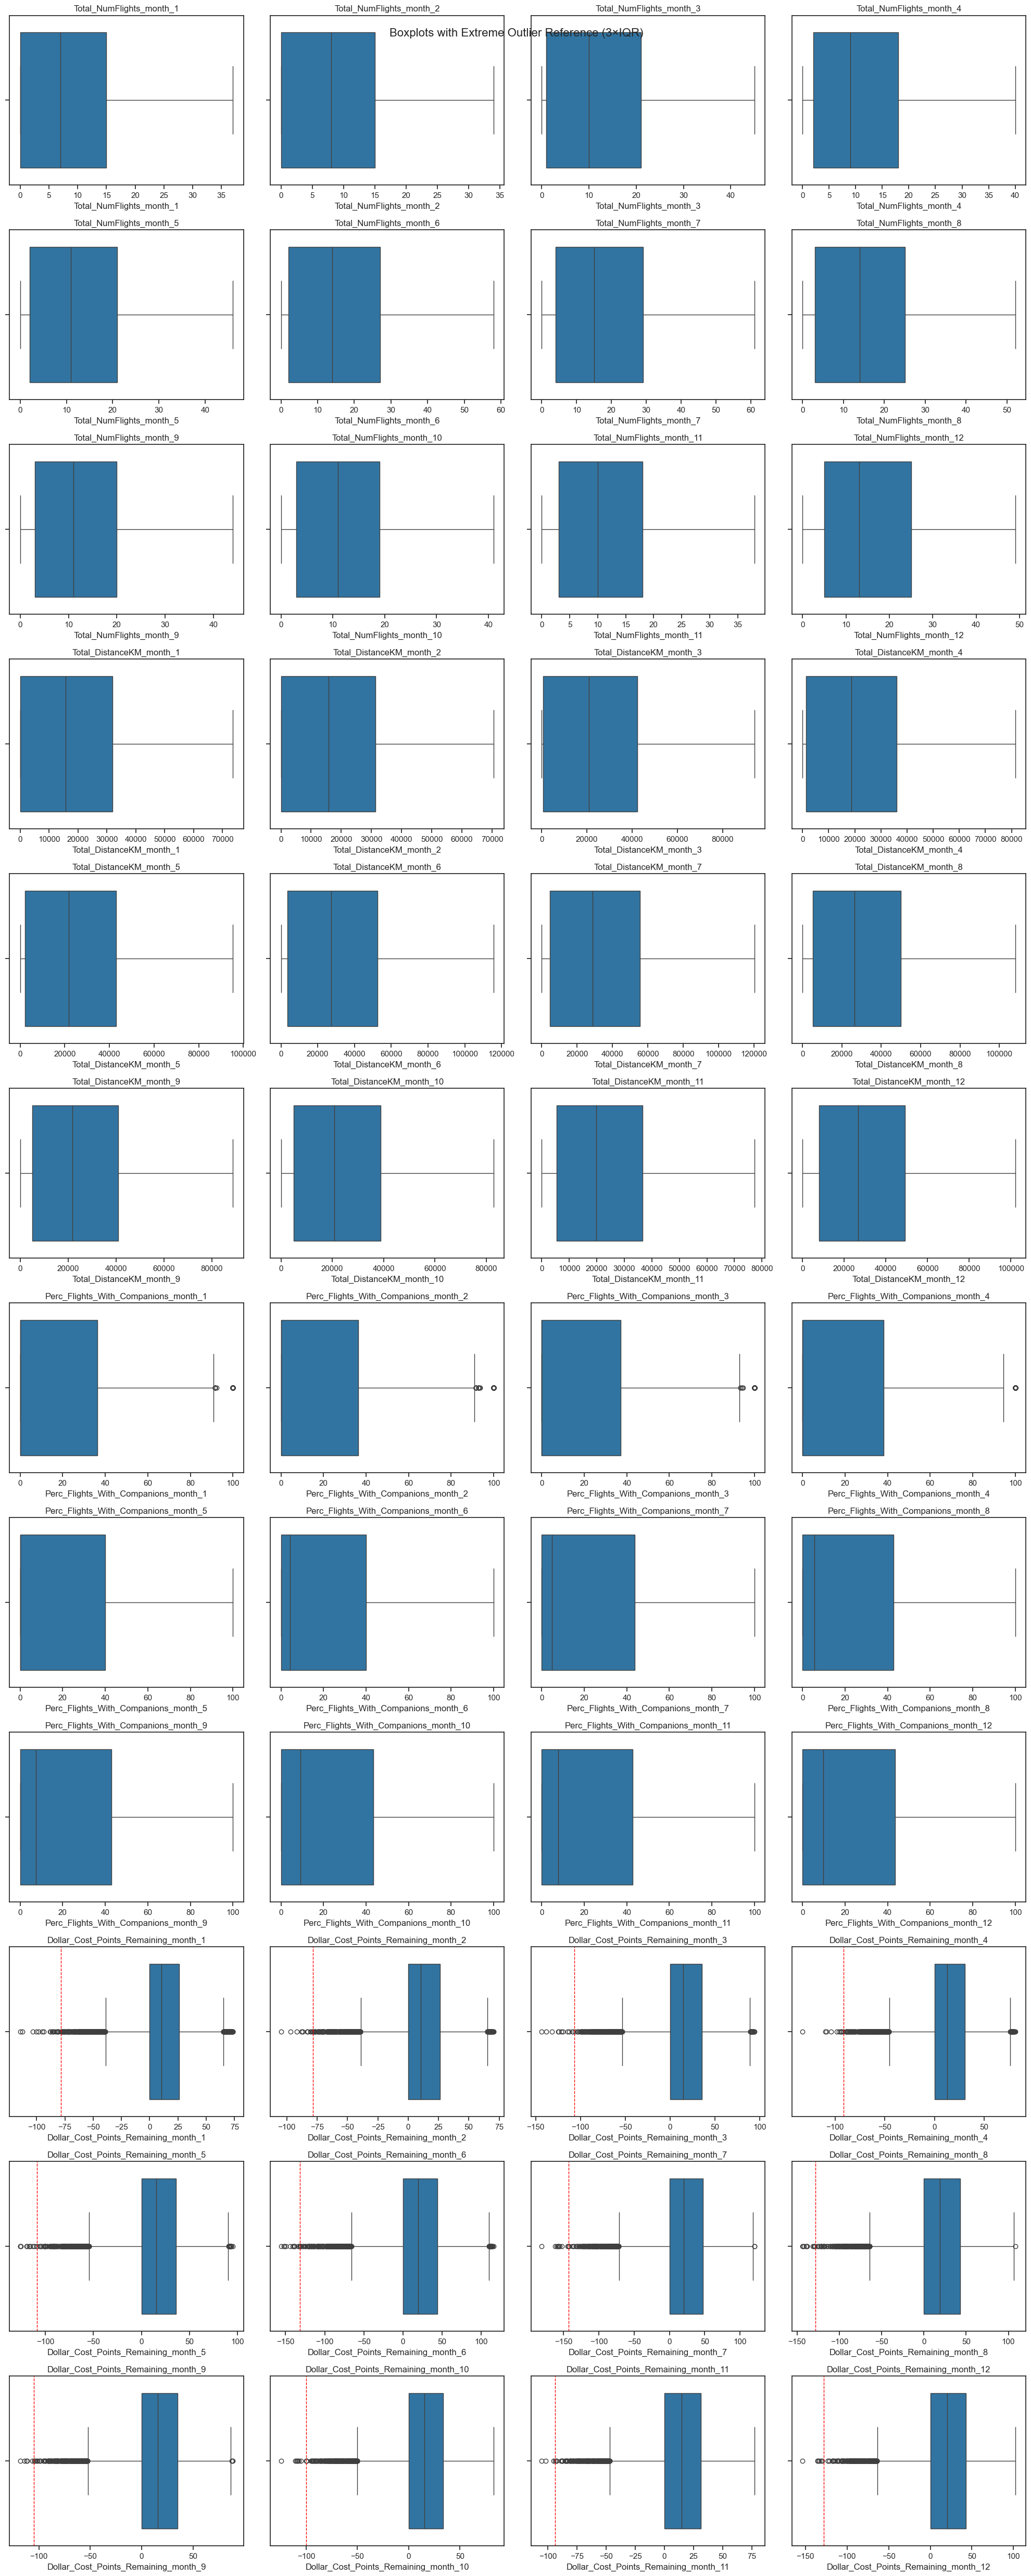

In [48]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [49]:
q1 = df_AIAI_M_Behavioral.quantile(0.25)
q3 = df_AIAI_M_Behavioral.quantile(0.75)
iqr = q3 - q1
lower_extreme = q1 - 3 * iqr
upper_extreme = q3 + 3 * iqr

# Cap values to the extreme bounds
df_AIAI_M_Behavioral = df_AIAI_M_Behavioral.copy()
for col in df_AIAI_M_Behavioral.columns:
    df_AIAI_M_Behavioral[col] = df_AIAI_M_Behavioral[col].clip(lower=lower_extreme[col], upper=upper_extreme[col])


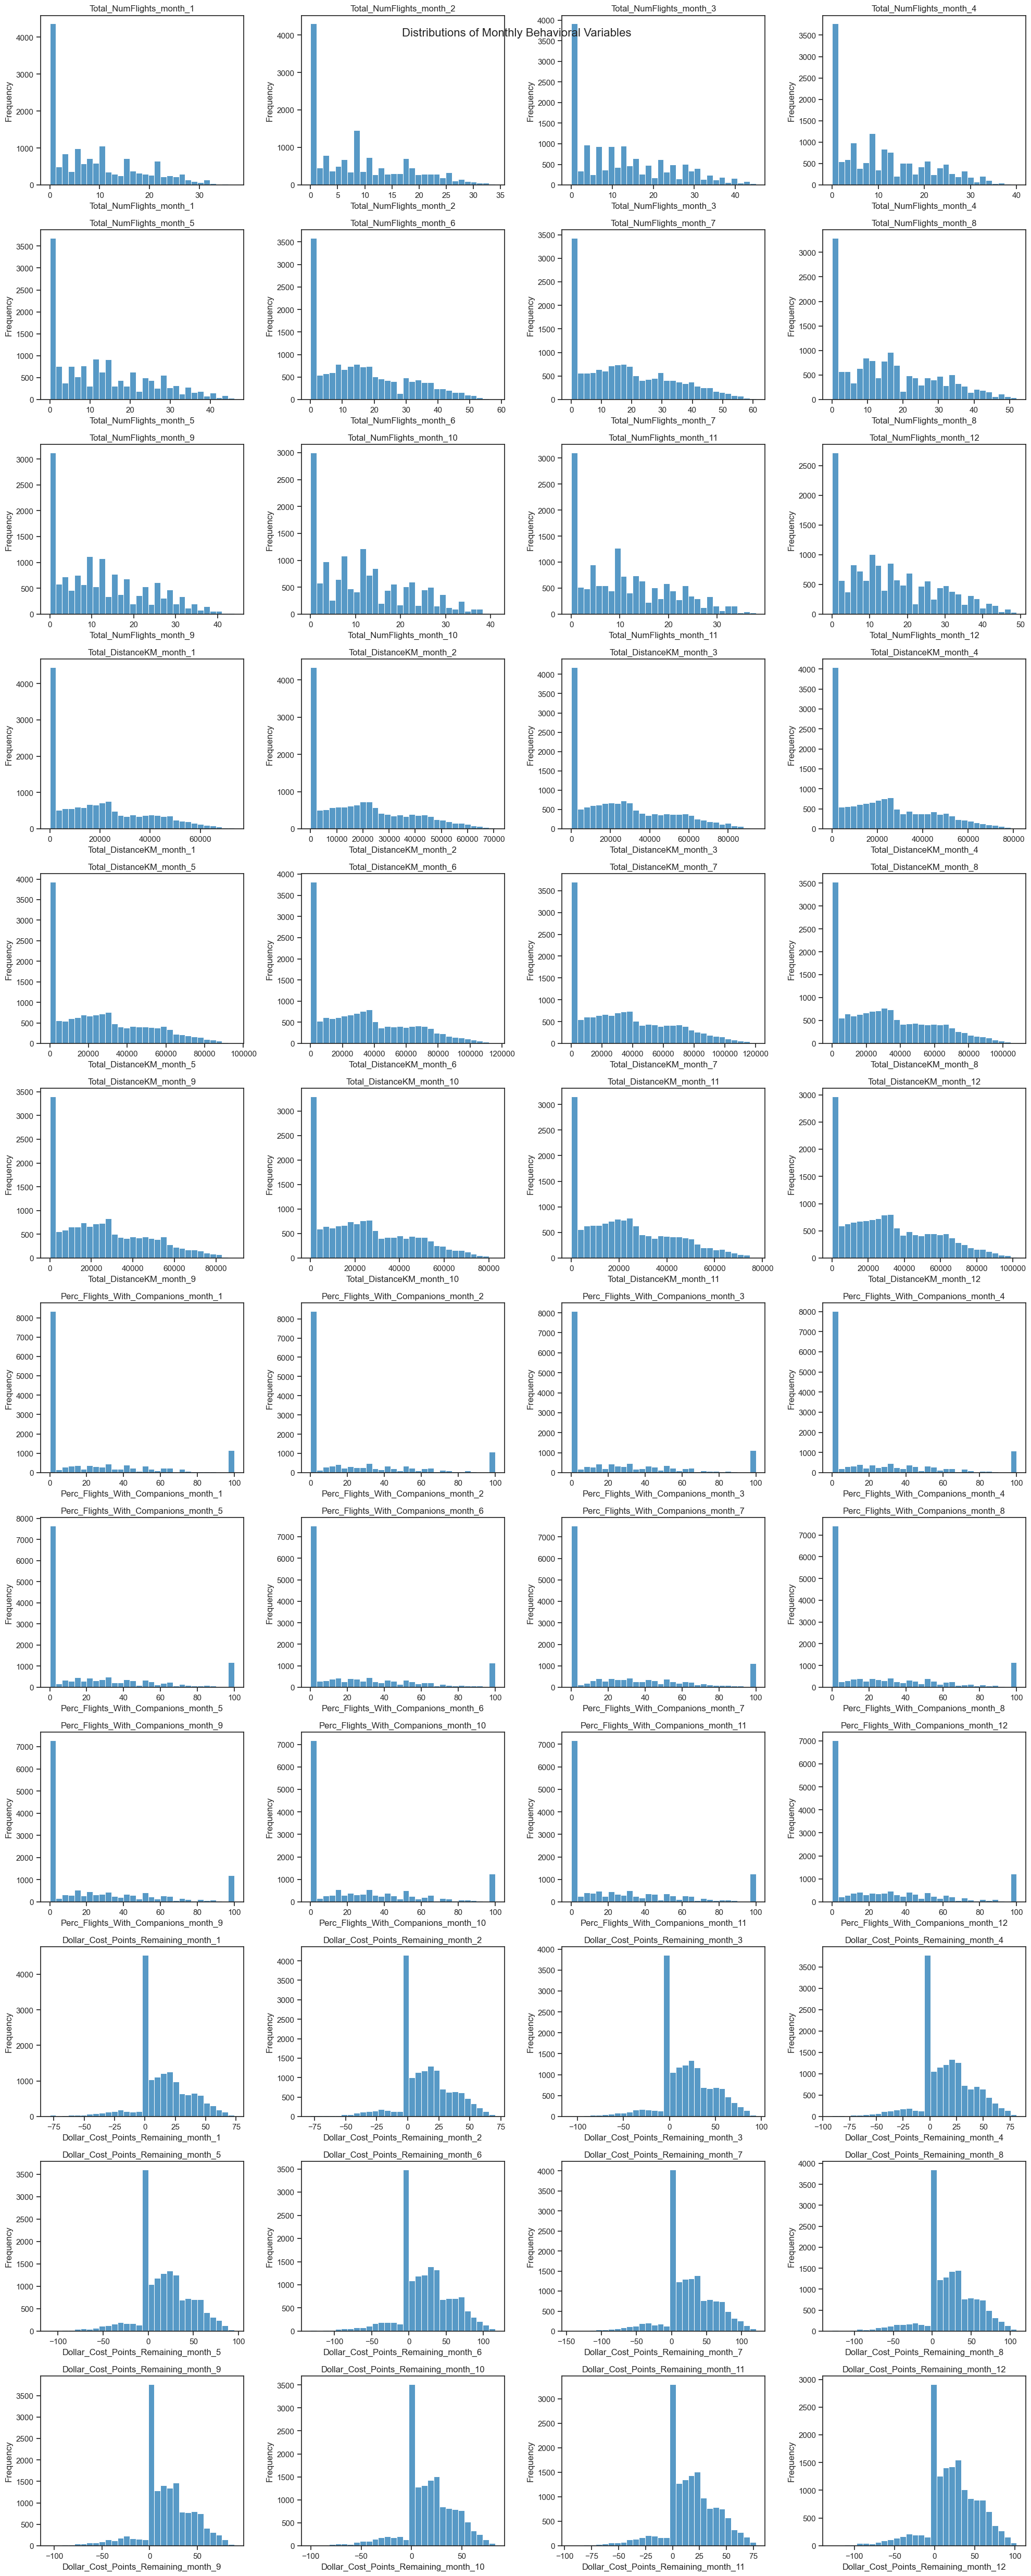

In [50]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Monthly Behavioral Variables", fontsize=16)
plt.tight_layout()
plt.show()

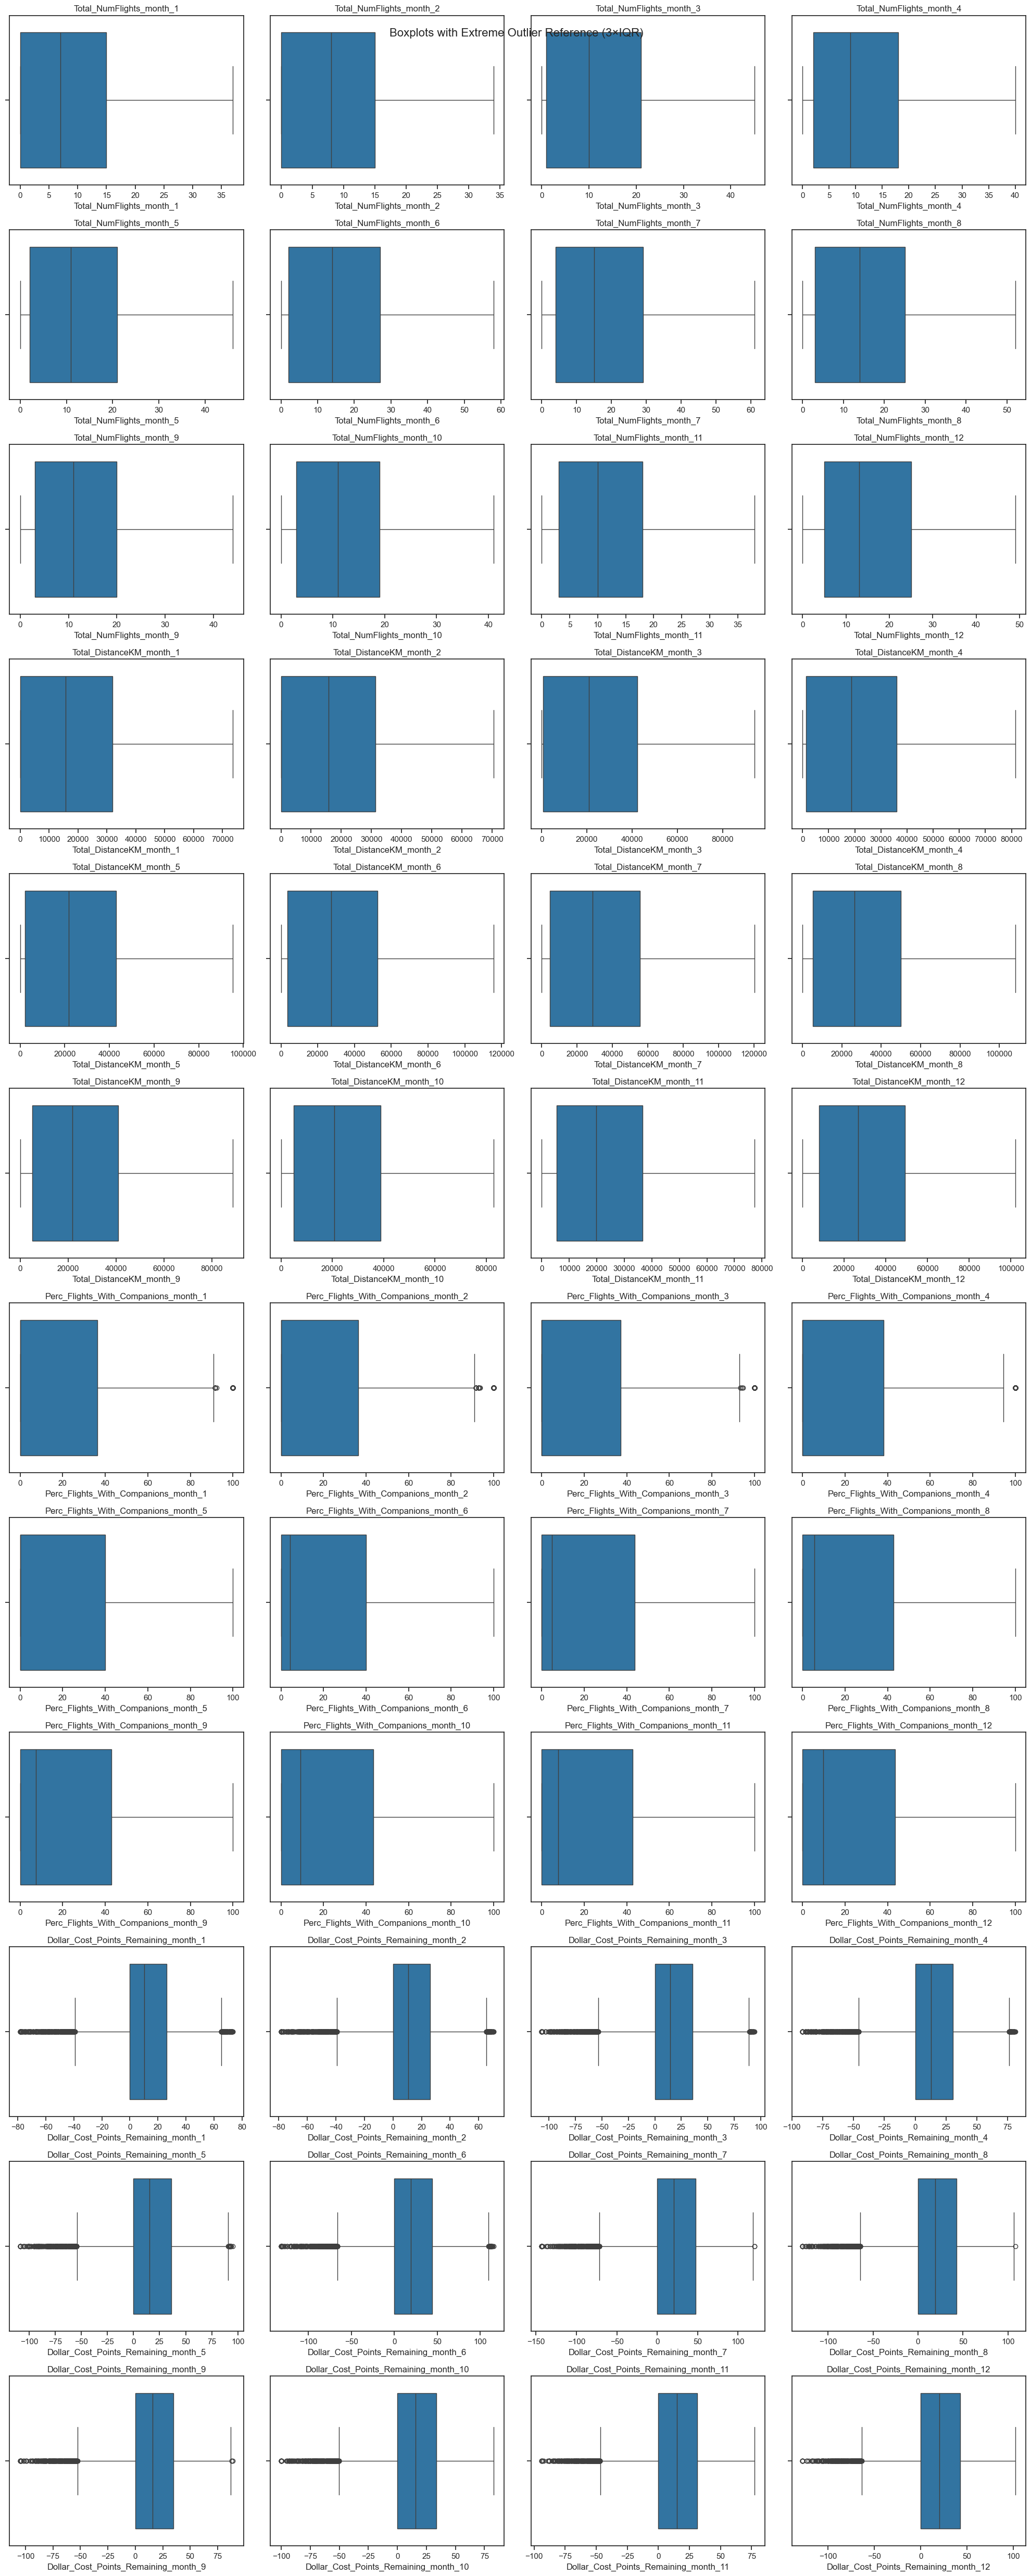

In [51]:
fig, axes = plt.subplots(12, 4, figsize=(20, 50))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_M_Behavioral.columns):
    
    data = df_AIAI_M_Behavioral[col]
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()

Scale

In [80]:
scaler = MinMaxScaler(feature_range= (-1,1) )
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_AIAI_M_Behavioral),
    index=df_AIAI_M_Behavioral.index,
    columns=df_AIAI_M_Behavioral.columns
)

In [81]:
df_for_modeling.head()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,-0.891892,-0.529412,-0.911111,-0.35,0.391304,-0.172414,-0.016393,0.192308,-0.227273,-0.609756,-0.210526,-0.632653,-0.315672,0.857947,-0.738060,-0.881069,0.451549,-0.241395,-0.173170,-0.168358,0.002735,0.712493,-0.450050,-0.117143,-1.000000,-0.500000,1.000000,-0.538462,-0.375000,-1.000000,-1.0,-0.290323,0.176471,0.000000,0.466667,-0.333333,0.362942,0.933138,0.186312,0.115698,0.743965,0.419770,0.463930,0.466234,0.542396,0.464049,-0.187678,0.047650
549612,0.297297,0.000000,0.422222,-0.50,0.826087,-0.586207,0.180328,0.384615,-0.545455,0.365854,0.105263,-0.551020,-0.287835,-0.258960,-0.388021,-0.755308,0.216922,-0.946818,-0.335845,0.420826,-0.452429,-0.186522,-0.070931,-0.468064,-0.500000,-1.000000,-1.000000,-0.400000,-1.000000,-0.166667,-0.5,-0.500000,-1.000000,-1.000000,-1.000000,-1.000000,0.022980,0.404176,0.350153,0.174948,0.634326,0.090104,-1.000000,0.735342,0.333519,0.462776,0.516518,0.347975
429460,0.135135,-0.529412,-0.333333,-1.00,0.000000,-1.000000,-1.000000,-0.192308,-0.318182,-1.000000,-0.210526,-0.918367,0.814979,-0.827058,-0.354800,-1.000000,-0.871819,-1.000000,-1.000000,-0.687635,0.279120,-1.000000,-0.973336,-0.103448,-1.000000,0.500000,0.733333,-1.000000,-0.826087,-1.000000,-1.0,0.619048,-1.000000,-1.000000,-1.000000,1.000000,0.910469,-0.601283,0.365727,0.059578,0.125869,0.065304,0.086147,0.229050,0.669214,0.094675,0.109210,0.509886
608370,-0.405405,0.235294,0.377778,-0.35,0.043478,0.275862,-1.000000,-1.000000,-0.136364,0.073171,-0.894737,-0.346939,0.338997,-0.001376,0.395673,-0.079418,-0.198104,-0.219825,-1.000000,-1.000000,-0.790989,0.282342,-0.243030,-0.541125,0.454545,0.047619,-0.161290,-1.000000,-0.666667,-1.000000,-1.0,-1.000000,-0.789474,0.181818,-1.000000,-0.125000,-0.149340,-0.370056,0.717038,0.493880,0.440563,0.429871,0.086147,0.086398,0.178134,0.675157,0.438929,0.022709
530508,-1.000000,0.294118,-0.822222,-1.00,0.043478,-0.482759,-0.311475,0.461538,-0.636364,-1.000000,0.263158,-0.387755,-1.000000,-0.440327,-0.881698,-1.000000,-0.011769,-0.065584,-0.078443,0.358764,0.538082,-1.000000,0.057832,-0.958425,-1.000000,-0.181818,1.000000,-1.000000,-0.500000,0.200000,-1.0,-0.315789,1.000000,-1.000000,-0.166667,-0.466667,0.031536,0.318040,0.119040,0.059578,0.527517,0.501992,0.507169,0.707008,0.788100,0.094675,0.574629,0.130157


In [82]:
df_for_modeling.describe()

,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
count,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000,15101.000000
mean,-0.505098,-0.465384,-0.450279,-0.467770,-0.428814,-0.446977,-0.414359,-0.397992,-0.426624,-0.415125,-0.405118,-0.372462,-0.479911,-0.464947,-0.462744,-0.460390,-0.456624,-0.450406,-0.440670,-0.436991,-0.434570,-0.425362,-0.412945,-0.404848,-0.572823,-0.573821,-0.564273,-0.559299,-0.533858,-0.530834,-0.507782,-0.515661,-0.508272,-0.496770,-0.508666,-0.492142,0.207437,0.229847,0.241166,0.235562,0.243045,0.243821,0.265667,0.265247,0.261347,0.276648,0.283462,0.295941
std,0.479096,0.505221,0.512471,0.487038,0.515396,0.494023,0.499234,0.515169,0.485600,0.488195,0.497011,0.507632,0.500496,0.507060,0.504546,0.497708,0.495828,0.495040,0.499527,0.493497,0.489115,0.492997,0.497009,0.492442,0.625233,0.625727,0.624228,0.623379,0.635101,0.635792,0.641423,0.643093,0.642386,0.644729,0.644597,0.644589,0.296956,0.293746,0.289493,0.292752,0.287995,0.290001,0.284778,0.286168,0.286892,0.283387,0.285717,0.283759
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,-0.955556,-0.900000,-0.913043,-0.931034,-0.868852,-0.884615,-0.863636,-0.853659,-0.842105,-0.795918,-1.000000,-1.000000,-0.986015,-0.967466,-0.954119,-0.939057,-0.922572,-0.903983,-0.887627,-0.879996,-0.859924,-0.844318,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.031536,0.053159,0.063711,0.059578,0.066059,0.065304,0.086147,0.086398,0.082287,0.094675,0.097198,0.111708
50%,

In [83]:
range_clusters = range(1, 20)

inertia = []
for n_clus in range_clusters:  # iterate over desired ncluster range
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', random_state=22)
    kmclust.fit(df_for_modeling)
    inertia.append(kmclust.inertia_) 

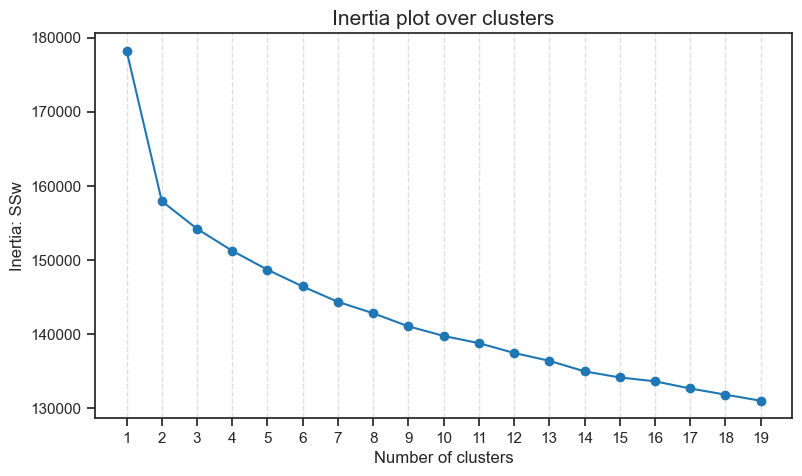

In [84]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia, marker='o', zorder=2)
ax.set_xticks(list(range_clusters))

# draw vertical dashed background lines at each cluster number
for x in range_clusters:
    ax.axvline(x, color='lightgray', linestyle='--', linewidth=1, zorder=0, alpha=0.7)

ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In [87]:
# final cluster solution
number_clusters = 2
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(df_for_modeling)
km_labels

array([1, 1, 1, ..., 1, 1, 0], dtype=int32)

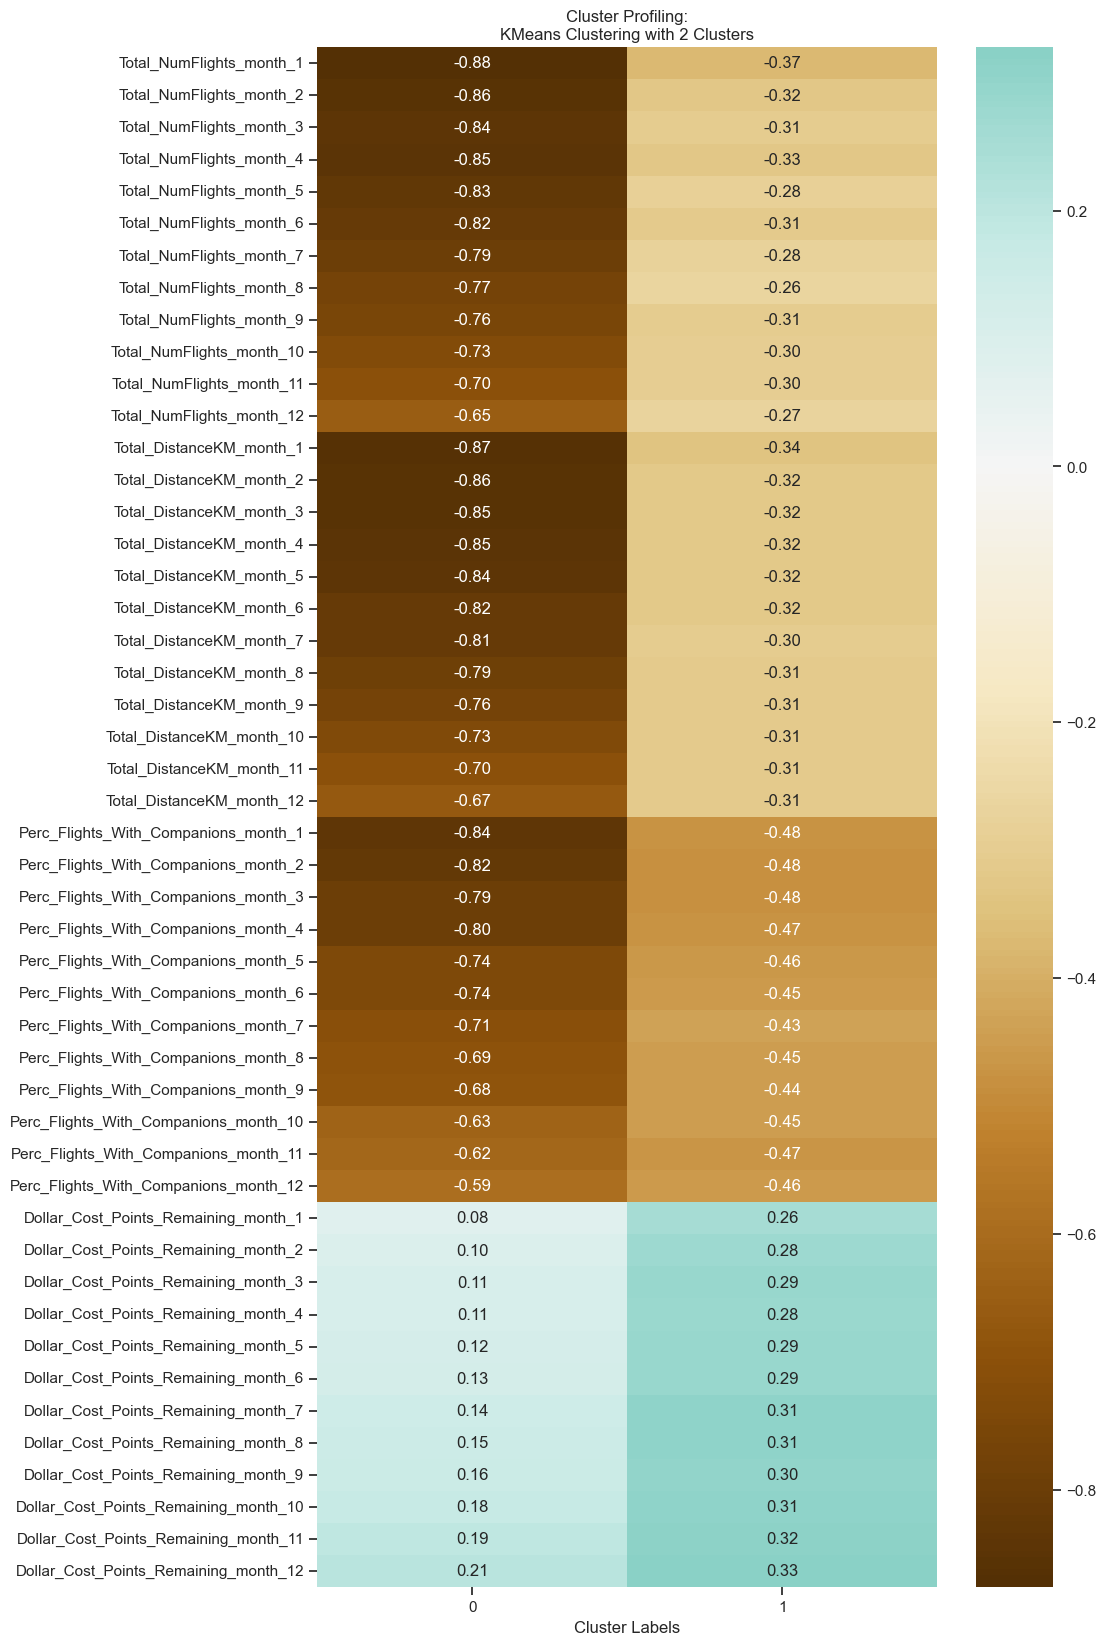

In [88]:
# Characterizing the final clusters
df_concat = pd.concat((df_for_modeling, pd.Series(km_labels, name='labels', index=df_for_modeling.index)), axis=1)

fig, ax = plt.subplots(figsize=(10,20))

km_profile = df_concat.groupby('labels').mean().T

sns.heatmap(km_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 2 Clusters")
plt.show()

In [100]:
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=5)
hc_labels = hclust.fit_predict(df_AIAI_Behavioral_year)
hc_labels

array([4, 1, 2, ..., 4, 0, 2])

In [ ]:
labels_series = pd.Series(hc_labels, 
                          name='labels', 
                          index=df_AIAI_Behavioral_year.index # WHY df.index ??
                          ) 

df_concat = pd.concat(
    [df_AIAI_Behavioral_year, labels_series],
    axis=1)


#df_concat

#df_concat[metric_features+['labels']].groupby('labels').mean()


In [111]:
# NUMPY solution:

# x_i       : X = df.values     : data
# x_bar     : X.mean(axis=0)    : centroid of data
# x_k       : X[hc_labels==k]   : points of cluster k
# x_bar_k   : X_k.mean(axis=0)  : centroid of cluster k
# n_k       : X_k.shape[0]

X = df_AIAI_Behavioral_year.values

# Computing SST
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)
print(f"SSt: {sst}")

# Computing SSW
ssw_iter = []                   # Outer summation
for i in np.unique(hc_labels):  # Loop for inner summation
    X_k = X[hc_labels == i]     # Data points belonging to cluster k
    inner_sum = np.sum(np.square(X_k - X_k.mean(axis=0)), axis=0)
    ssw_iter.append(inner_sum)  
ssw_per_feature = np.sum(ssw_iter, axis=0)  # Outer summation
ssw = np.sum(ssw_per_feature, axis=0)
print(f"SSw: {ssw}")

# Computing SSB
ssb_iter = []
for i in np.unique(hc_labels):  # Loop for summation
    X_k = X[hc_labels == i]     # Data points belonging to cluster k
    ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))

ssb_per_feature = np.sum(ssb_iter, axis=0)
ssb = np.sum(ssb_per_feature, axis=0)
print(f"SSb: {ssb}")

# Verifying the formula
np.round(sst) == np.round((ssw + ssb))

SSt: 139969043446939.03
SSw: 33317528161301.94
SSb: 106651515285637.17


np.True_

In [118]:
def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.

    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.

    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.

    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    
    return ss 


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns
    float: The between-group sum of squares of the DataFrame.
    """
    
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))) )

    ssb = np.sum(ssb_i)
    

    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.

    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats+[label_col]

    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats), 
        include_groups=False
        )

    return df_k.sum()

In [119]:
def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.

    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """

    df_sst_ = get_ss(df, feats)                 # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)     # get ss within
    df_ssb_ = df_sst_ - df_ssw_                 # get ss between

    # r2 = ssb/sst 
    return (df_ssb_/df_sst_)

In [113]:
def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    """This function computes the R2 for a set of cluster solutions given by the application of a hierarchical method.
    The R2 is a measure of the homogenity of a cluster solution. It is based on SSt = SSw + SSb and R2 = SSb/SSt. 
    
    Parameters:
    df (DataFrame): Dataset to apply clustering
    link_method (str): either "ward", "complete", "average", "single"
    max_nclus (int): maximum number of clusters to compare the methods
    min_nclus (int): minimum number of clusters to compare the methods. Defaults to 1.
    dist (str): distance to use to compute the clustering solution. Must be a valid distance. Defaults to "euclidean".
    
    Returns:
    ndarray: R2 values for the range of cluster solutions
    """
    
    r2 = []  # where we will store the R2 metrics for each cluster solution
    feats = df.columns.tolist()
    
    for i in range(min_nclus, max_nclus+1):  # iterate over desired ncluster range
        
        # CODE HERE ####################################
        cluster = AgglomerativeClustering(linkage=link_method, metric=dist, n_clusters=i)
        
        #get cluster labels
        # CODE HERE ####################################
        hclabels = cluster.fit_predict(df[feats])
        
        # concat df with labels
        df_concat = pd.concat([df, pd.Series(hclabels, name='labels', index=df.index)], axis=1)  
        
        
        # append the R2 of the given cluster solution
        r2.append(get_rsq(df_concat, feats, 'labels'))
        
    return np.array(r2)